In [1]:
import math
import numpy as np
import scipy.stats as scs
import statsmodels.api as sm
from pylab import mpl, plt

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [3]:
def gen_paths(S0, r, sigma, T, M, I):
    '''Generate Monte Carlo paths for geometric Brownian Motion.

    Parameters 
    ==========
    S0: float
        initial stock/index value
    r: float
        constant short rate
    sigma: float 
        constant volatility
    T: float
        final time horizaon
    M: int
        number of time steps/intervals
    I: int
        number of paths to be simulated

    Returns
    =======
    paths: ndarray, shape (M + 1, I) 
        simulated paths given the parameters
    '''
    dt = T / M
    paths = np.zeros((M + 1, I))
    paths[0] = S0 
    for t in range(1, M + 1):
        rand = np.random.standard_normal(I)
        rand = (rand - rand.mean())/ rand.std()
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma ** 2) * dt +
                                       sigma * math.sqrt(dt) * rand)
    return paths

In [4]:
S0 = 100.
r = 0.05
sigma = 0.2
T = 1.0
M = 50
I = 250000
np.random.seed(100)

In [5]:
paths = gen_paths(S0, r, sigma, T, M, I)

In [6]:
S0 * math.exp(r * T)

105.12710963760242

In [7]:
paths[-1].mean()

np.float64(105.1190446825246)

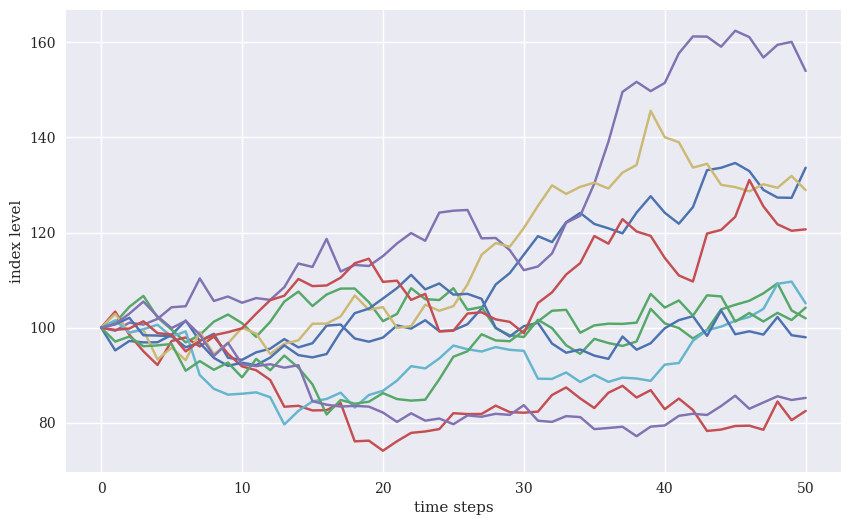

In [8]:
plt.figure(figsize=(10,6))
plt.plot(paths[:, :10])
plt.xlabel('time steps')
plt.ylabel('index level')
plt.show()

In [9]:
paths[:, 0].round(4)

array([100.    ,  95.2123,  97.1885,  96.8957,  96.9154,  98.4583,
       101.5003,  97.2147,  98.6952,  93.6604,  93.2283,  94.7991,
        95.5763,  97.5871,  95.8443,  96.7178, 100.4188, 100.6413,
        97.7141,  97.0397,  97.91  , 100.4595,  99.794 , 101.5602,
        99.2453,  99.4409, 100.7174, 104.0164, 109.0677, 111.4674,
       115.3495, 119.251 , 117.9906, 122.171 , 124.1345, 121.8086,
       120.8928, 119.8405, 124.2044, 127.6481, 124.1695, 121.8624,
       125.3535, 133.1199, 133.6297, 134.6331, 132.9387, 128.9693,
       127.3606, 127.3028, 133.6463])

In [10]:
log_returns = np.log(paths[1:] / paths[:-1])

In [11]:
log_returns[:, 0].round(4)

array([-0.0491,  0.0205, -0.003 ,  0.0002,  0.0158,  0.0304, -0.0431,
        0.0151, -0.0524, -0.0046,  0.0167,  0.0082,  0.0208, -0.018 ,
        0.0091,  0.0376,  0.0022, -0.0295, -0.0069,  0.0089,  0.0257,
       -0.0066,  0.0175, -0.0231,  0.002 ,  0.0128,  0.0322,  0.0474,
        0.0218,  0.0342,  0.0333, -0.0106,  0.0348,  0.0159, -0.0189,
       -0.0075, -0.0087,  0.0358,  0.0273, -0.0276, -0.0188,  0.0282,
        0.0601,  0.0038,  0.0075, -0.0127, -0.0303, -0.0126, -0.0005,
        0.0486])

In [12]:
def print_statistics(array):
    '''Print selected statistics

    Parameters
    ==========
    array: ndarray
        object to generate statistics on
    '''
    sta = scs.describe(array)
    print('%14s %15s' % ('statistic', 'value'))
    print( 30 * '-')
    print('%14s %15.5f' % ('size', sta[0]))
    print('%14s %15.5f' % ('min', sta[1][0]))
    print('%14s %15.5f' % ('max', sta[1][1]))
    print('%14s %15.5f' % ('mean', sta[2]))
    print('%14s %15.5f' % ('std', np.sqrt(sta[3])))
    print('%14s %15.5f' % ('skew', sta[4]))
    print('%14s %15.5f' % ('kurtosis', sta[5]))  

In [13]:
print_statistics(log_returns.flatten())

     statistic           value
------------------------------
          size  12500000.00000
           min        -0.14449
           max         0.15033
          mean         0.00060
           std         0.02828
          skew         0.00071
      kurtosis         0.00035


In [14]:
log_returns.mean() * M + 0.5 * sigma **2

np.float64(0.05000000000000006)

In [15]:
log_returns.std() * math.sqrt(M)

np.float64(0.20000000000000012)

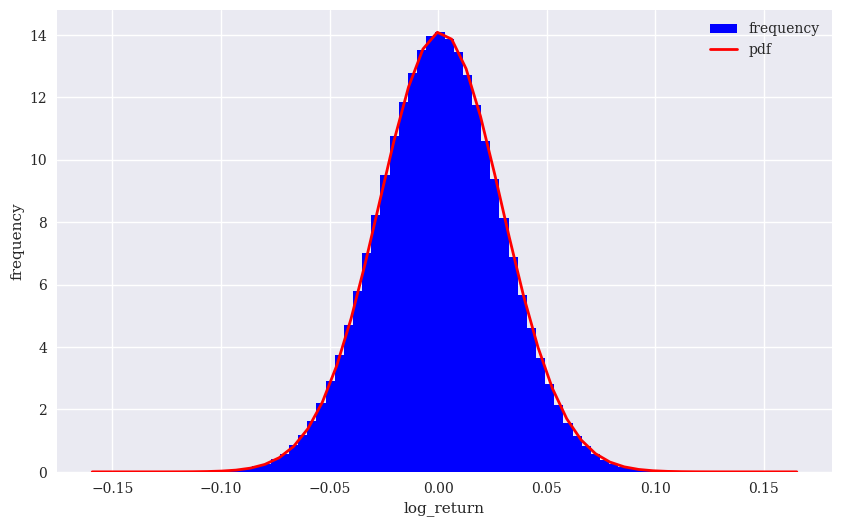

In [16]:
plt.figure(figsize=(10,6))
plt.hist(log_returns.flatten(), bins=70, density=True,
         label='frequency', color='b')
plt.xlabel('log_return')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, loc=r / M, scale = sigma / np.sqrt(M)), 'r', 
         lw=2.0, label='pdf')
plt.legend()
plt.show()

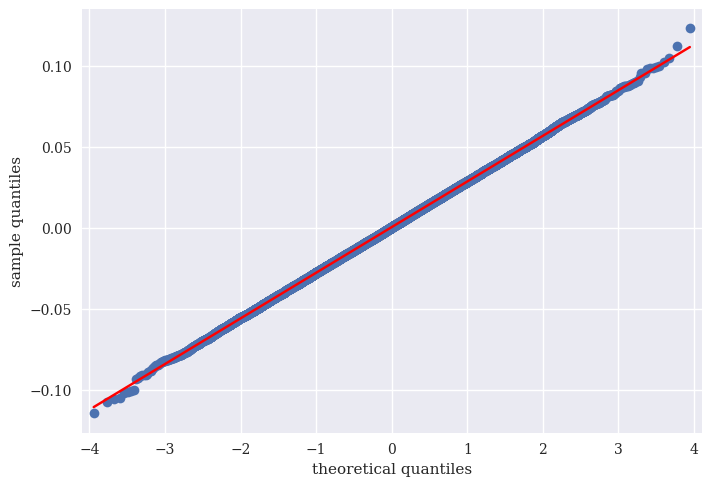

In [17]:
sm.qqplot(log_returns.flatten()[::500], line='s')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()

In [18]:
def normality_tests(arr):
    ''' Tests for normality distribution of given data set.

    Parameters
    ==========
    array: ndarray
      object to generate statistics on
    '''
    print('Skew of data set %14.3f' % scs.skew(arr))
    print('Skew test p-value %14.3f' % scs.skewtest(arr)[1])
    print('Kurt of data set %14.3f'  % scs.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scs.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scs.normaltest(arr)[1])

In [19]:
normality_tests(log_returns.flatten())

Skew of data set          0.001
Skew test p-value          0.303
Kurt of data set          0.000
Kurt test p-value          0.802
Norm test p-value          0.570


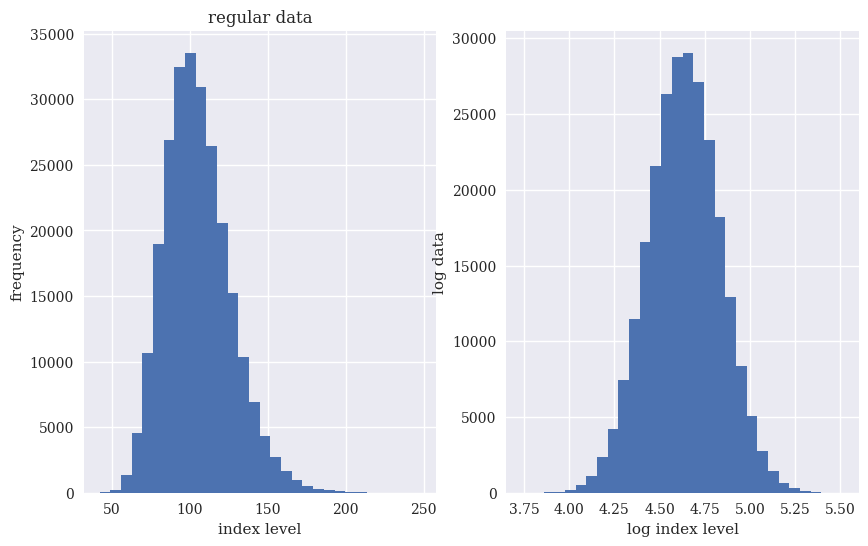

In [20]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(10,6))
ax1.hist(paths[-1], bins=30)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax1.set_title('regular data')
ax2.hist(np.log(paths[-1]), bins=30)
ax2.set_xlabel('log index level')
ax2.set_ylabel('log data')
plt.show()

In [21]:
print_statistics(paths[-1])

     statistic           value
------------------------------
          size    250000.00000
           min        42.14320
           max       247.66273
          mean       105.11904
           std        21.18909
          skew         0.60820
      kurtosis         0.65395


In [22]:
print_statistics(np.log(paths[-1]))

     statistic           value
------------------------------
          size    250000.00000
           min         3.74107
           max         5.51207
          mean         4.63517
           std         0.19964
          skew        -0.00308
      kurtosis        -0.00315


In [23]:
normality_tests(np.log(paths[-1]))

Skew of data set         -0.003
Skew test p-value          0.530
Kurt of data set         -0.003
Kurt test p-value          0.753
Norm test p-value          0.781


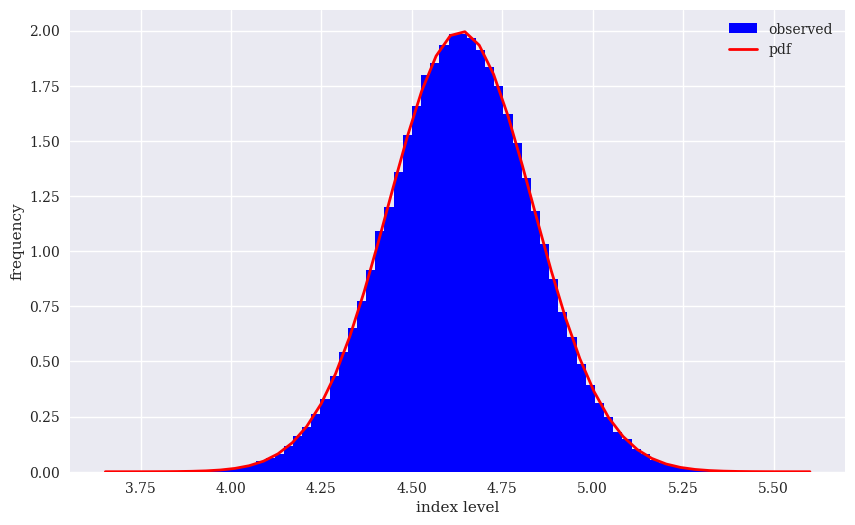

In [24]:
plt.figure(figsize=(10,6))
log_data = np.log(paths[-1])
plt.hist(log_data, bins=70, density=True,
         label='observed', color='b')
plt.xlabel('index level')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, log_data.mean(), log_data.std()),
         'r', lw=2.0, label='pdf')
plt.legend()
plt.show()

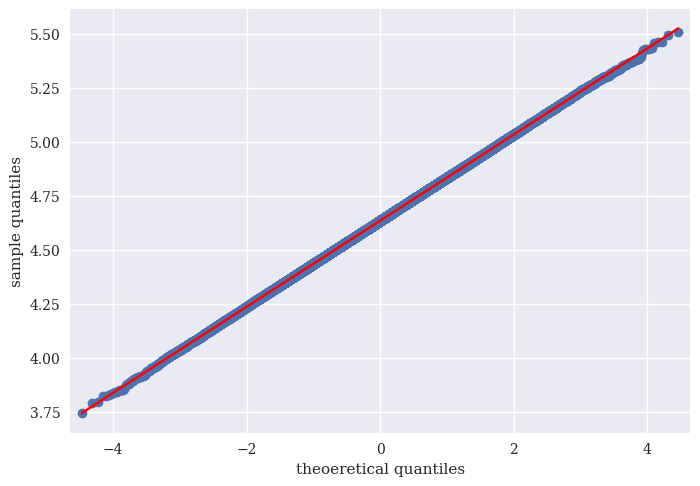

In [25]:
sm.qqplot(log_data, line='s')
plt.xlabel('theoeretical quantiles')
plt.ylabel('sample quantiles')
plt.show()

<span style='font-size:17px'><b>Normality Testing of Simulated GBM Log-Returns</b>

* <b>Simulation Set-up:</b> Using Geometric Brownian Motion with parameters $S_0 = 100$, $r = 0.05$, $\sigma = 0.20$, and a 1-year horizon divided into $M = 50$ time steps, we simulate $I = 250{,}000$ independent price paths - each one a possible future trajectory of the asset - producing a paths matrix of shape $(M+1, I)$.
* <b>Convergence of Monte Carlo Estimator:</b> The theoretical expected terminal price $S_0 e^{rT} \approx
  \textbf{105.127}$ is recovered almost exactly by the average simulated price of $\textbf{105.119}$ -  a discrepancy of less than $0.01\%$. This confirms that with enough paths, the simulation converges to the true mathematical expectation as predicted by the Law of Large Numbers.
* <b>Normality of Log-Returns:</b> Across all $12{,}500{,}000$ log-return observations, skewness is **0.001** and excess kurtosis is <b>0.000</b> - both essentially zero - with all normality test p-values well above <b>0.05</b>. This means we cannot distinguish the simulated returns from true normal distribution, exactly as GBM theory requires.
* <b>Log-Normality of Terminal Prices:</b> The raw terminal prices $S_T$ are right-skewed (skewness <b>0.608</b>), meaning large upside outcomes are more common than large losses - consistent with the fact that prices cannot go below zero. Once we take the log of prices, the skewness collapses to <b>-0.003</b>, confirming that log-prices are normally distibuted as GBM theory predicts.
* <b>Visual Confirmation:</b> The empirical log-returns hostrogram aligns precisely with theoretical normal PDF, and the Q-Q plot - which compares our simulated quantiles against a perfect normal distribution - shows points lying almost exactly on the 45 degree reference line, jointly validating the normality assumption across the full distribution.

In [26]:
!pip install yfinance

In [27]:
import yfinance as yf
import pandas as pd

In [28]:
tickers = ['SPY',  'GLD', 'AAPL', 'MSFT']
raw = yf.download(tickers, start='2010-01-01', end='2024-01-01', auto_adjust=False)['Close']
raw = raw.dropna()
raw['AAPL'] = raw['AAPL'] * 4
raw.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,GLD,MSFT,SPY
Date,,,,
2010-01-04,30.572857,109.800003,30.950001,113.330002
2010-01-05,30.625715,109.699997,30.959999,113.629997
2010-01-06,30.138573,111.510002,30.770000,113.709999
2010-01-07,30.082855,110.820000,30.450001,114.190002
2010-01-08,30.282856,111.370003,30.660000,114.570000


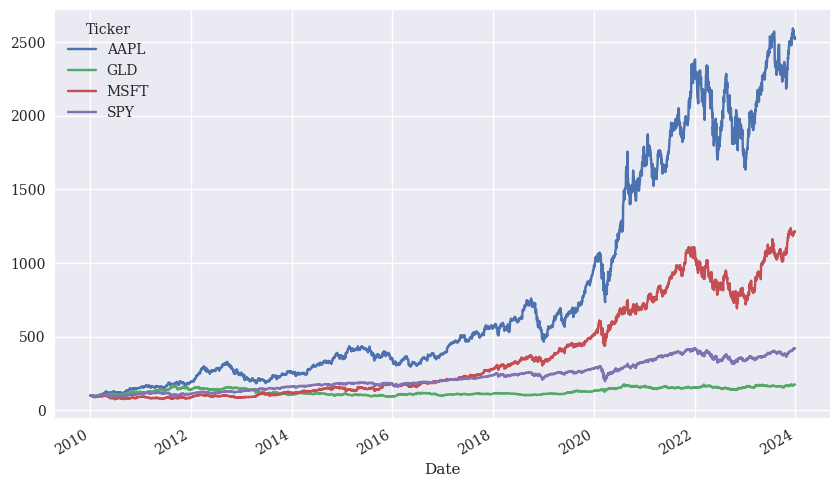

In [29]:
(raw / raw.iloc[0] * 100).plot(figsize=(10,6))
plt.show()

In [30]:
log_returns = np.log(raw/raw.shift(1))
log_returns.head()

Ticker,AAPL,GLD,MSFT,SPY
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.001727,-0.000911,0.000323,0.002644
2010-01-06,-0.016034,0.016365,-0.006156,0.000704
2010-01-07,-0.001850,-0.006207,-0.010454,0.004212
2010-01-08,0.006626,0.004951,0.006873,0.003322


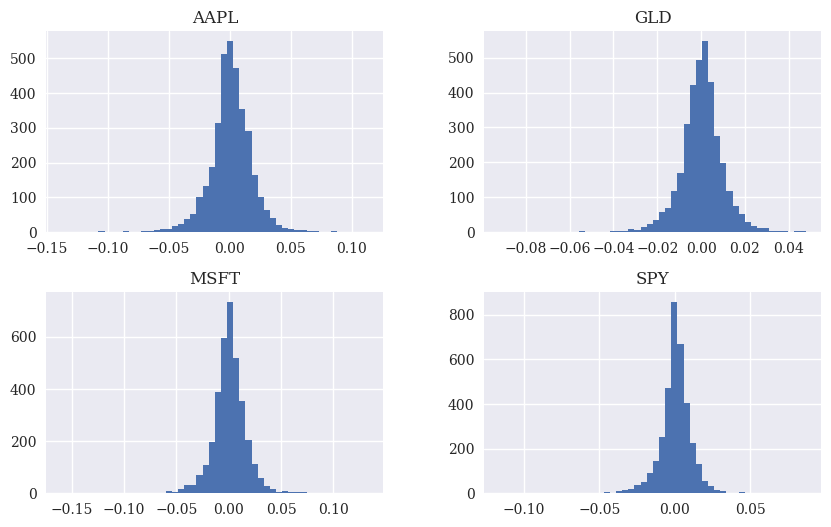

In [31]:
log_returns.hist(bins=50, figsize=(10,6))
plt.show()

In [32]:
for tick in tickers:
    print('\nResults for symbol {}'.format(tick))
    print(30 * '-')
    log_data = np.array(log_returns[tick].dropna())
    print_statistics(log_data)


Results for symbol SPY
------------------------------
     statistic           value
------------------------------
          size      3521.00000
           min        -0.11589
           max         0.08673
          mean         0.00041
           std         0.01099
          skew        -0.71043
      kurtosis        11.33308

Results for symbol GLD
------------------------------
     statistic           value
------------------------------
          size      3521.00000
           min        -0.09191
           max         0.04787
          mean         0.00016
           std         0.00980
          skew        -0.50231
      kurtosis         5.04473

Results for symbol AAPL
------------------------------
     statistic           value
------------------------------
          size      3521.00000
           min        -0.13771
           max         0.11316
          mean         0.00092
           std         0.01778
          skew        -0.25028
      kurtosis         5.420

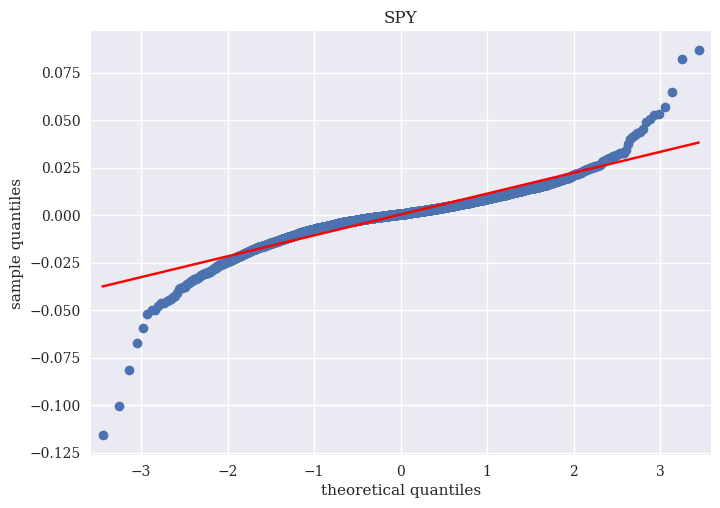

In [33]:
sm.qqplot(log_returns['SPY'].dropna(), line='s')
plt.title('SPY')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()

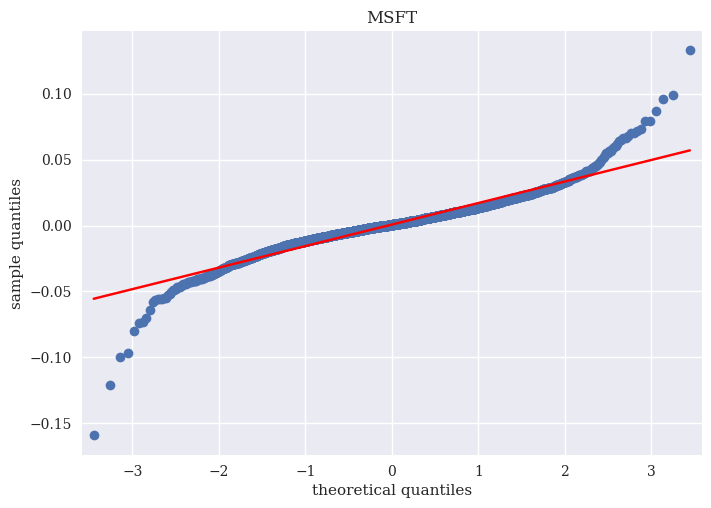

In [34]:
sm.qqplot(log_returns['MSFT'].dropna(), line='s')
plt.title('MSFT')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()

In [35]:
for tick in tickers:
    print('\Results for symbol {}'.format(tick))
    print(32 * '-')
    log_data = np.array(log_returns[tick].dropna())
    normality_tests(log_data)

\Results for symbol SPY
--------------------------------
Skew of data set         -0.710
Skew test p-value          0.000
Kurt of data set         11.333
Kurt test p-value          0.000
Norm test p-value          0.000
\Results for symbol GLD
--------------------------------
Skew of data set         -0.502
Skew test p-value          0.000
Kurt of data set          5.045
Kurt test p-value          0.000
Norm test p-value          0.000
\Results for symbol AAPL
--------------------------------
Skew of data set         -0.250
Skew test p-value          0.000
Kurt of data set          5.421
Kurt test p-value          0.000
Norm test p-value          0.000
\Results for symbol MSFT
--------------------------------
Skew of data set         -0.181
Skew test p-value          0.000
Kurt of data set          8.000
Kurt test p-value          0.000
Norm test p-value          0.000


<span style='font-size:17px'><b>Normality Testing of Real Financial Return Data: SPY, GLD, AAPL & MSFT</b>

* <b>Data & Log_Return Construction:</b> Daily closing prices for SPY, GLD, AAPL, MSFT are sourced from 2010-01-01 to 2024-01-01, yielding $N = 3{,}521$ observations per ticker. Log-returns are computed as $r_t = \log(S_t / S_{t-1})$, capturing the continuously compounded daily return for each asset.
* <b>Departure from Normality - Skewness and Fat Tails:</b> Unlike the simulated GBM returns, all four assets exhibit <b>negative skewness</b> (SPY: $-0.710$, GLD: $-.502$, AAPL:$-0.250$, MSFT: $-0.181$) - indicating that large negative returns occur more frequently than large positive ones. More strikingly, excess kurtosis is severly elevated across all tickers (SPY:<b>11.333</b>,MSFT: <b>7.99</b>, AAPL:<b>5.421</b>, GLD: <b>5.045</b>), confirming that extreme return events occur far more often than a normal distribution would predict.
* <b>Formal Rejection of Normality:</b> Every normality test p-value across all four tickers rounds to <b>0.000</b> - an overwhelming rejection of the null hypothesis of normality at any conventional significance level. This stands in sharp contrast to the simulated GBM data, where all p-values exceeded 0.30, and confirms that real market returns carry <b>fat tails and asymmetric crash risk</b> not captured by the Gaussian assumption.
* <b>Q-Q Plot Confirmation:</b> The Q-Q plots for SPY and MSFT show the classic S-curve deviation from the 45 degrees reference line - dots divergingly sharply in both tails - visually reinforcing that extreme moves on both the upside and downside occur far more frequently than normality predict. This has direct implications for risk management, as models assuming normality will systematically <b>underestimate tail-risk</b> in live market conditions.

In [36]:
symbols = ['AAPL', 'MSFT', 'SPY', 'GLD']

In [37]:
noa = len(symbols)

In [38]:
data = raw[symbols]

In [39]:
rets = np.log(data/ data.shift(1))

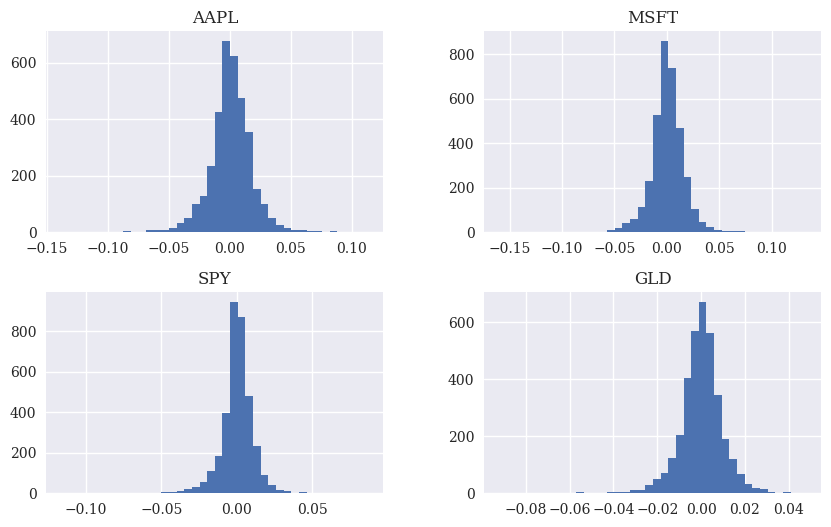

In [40]:
rets.hist(bins=40, figsize=(10,6))
plt.show()

In [41]:
rets.mean() * 252

Ticker
AAPL    0.230918
MSFT    0.178735
SPY     0.102608
GLD     0.039686
dtype: float64

In [42]:
rets.cov() * 252

Ticker,AAPL,MSFT,SPY,GLD
Ticker,,,,
AAPL,0.079700,0.043465,0.034012,0.002268
MSFT,0.043465,0.067370,0.034143,0.001177
SPY,0.034012,0.034143,0.030429,0.001162
GLD,0.002268,0.001177,0.001162,0.024226


In [43]:
weights = np.random.random(noa)
weights /= np.sum(weights)

In [44]:
weights

array([0.33177382, 0.19570717, 0.17415737, 0.29836164])

In [45]:
weights.sum()

np.float64(1.0)

In [46]:
np.sum(rets.mean()*weights) *252

np.float64(0.14130289681622465)

In [47]:
np.dot(weights.T, np.dot(rets.cov() *252, weights))

np.float64(0.027042516028471228)

In [48]:
math.sqrt(np.dot(weights.T,np.dot(rets.cov()*252, weights)))

0.16444608851678785

In [49]:
def port_ret(weights):
    return np.sum(rets.mean() * weights) *252

In [50]:
def port_vol(weights):
    return np.sqrt(np.dot(weights.T, np.dot(rets.cov()* 252, weights)))

In [51]:
prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(noa)
    weights /= np.sum(weights)
    prets.append(port_ret(weights))
    pvols.append(port_vol(weights))
prets = np.array(prets)
pvols = np.array(pvols)

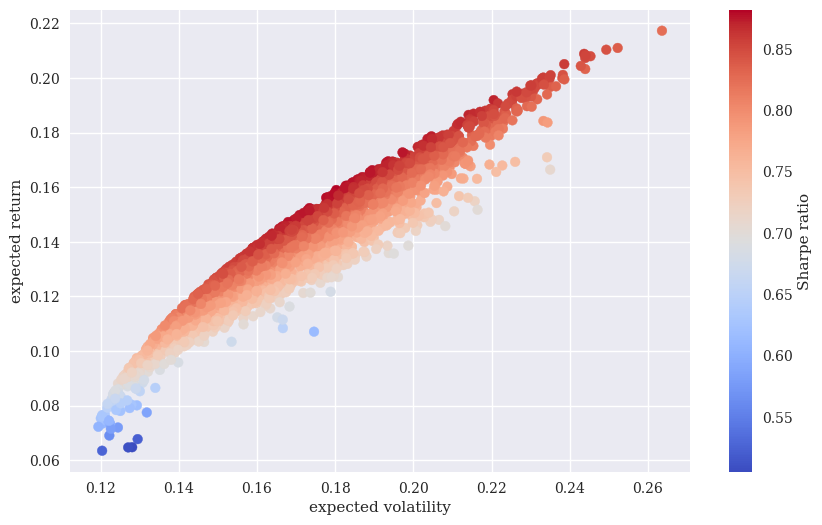

In [52]:
plt.figure(figsize=(10,6))
plt.scatter(pvols, prets, c=prets / pvols,
            marker = 'o', cmap = 'coolwarm')
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio')
plt.show()

In [53]:
import scipy.optimize as sco

In [54]:
def min_func_sharpe(weights):
    return -port_ret(weights) / port_vol(weights)

In [55]:
cons = ({'type': 'eq','fun': lambda x: np.sum(x) -1})

In [56]:
bnds = tuple((0,1) for x in range(noa))

In [57]:
eweights = np.array(noa * [1. / noa,])
eweights

array([0.25, 0.25, 0.25, 0.25])

In [58]:
min_func_sharpe(eweights)

np.float64(-0.8376475719925193)

In [59]:
%%time 
opts = sco.minimize(min_func_sharpe, eweights, 
                    method = 'SLSQP', bounds = bnds,
                    constraints = cons)

CPU times: total: 78.1 ms
Wall time: 67.3 ms


In [60]:
opts

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.8823128737776474
       x: [ 4.599e-01  2.534e-01  3.285e-17  2.867e-01]
     nit: 6
     jac: [ 2.009e-04  1.402e-04  8.183e-02 -4.462e-04]
    nfev: 30
    njev: 6

In [61]:
opts['x'].round(3)

array([0.46 , 0.253, 0.   , 0.287])

In [62]:
port_ret(opts['x']),round(3)

(np.float64(0.1628754996771599), 3)

In [63]:
port_vol(opts['x']).round(3)

np.float64(0.185)

In [64]:
port_ret(opts['x']) / port_vol(opts['x'])

np.float64(0.8823128737776474)

In [65]:
optv = sco.minimize(port_vol, eweights,
                    method = 'SLSQP', bounds=bnds,
                    constraints=cons)

In [66]:
optv

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.11858041764438226
       x: [ 0.000e+00  0.000e+00  4.418e-01  5.582e-01]
     nit: 7
     jac: [ 1.374e-01  1.328e-01  1.188e-01  1.184e-01]
    nfev: 35
    njev: 7

In [67]:
optv['x'].round(3)

array([0.   , 0.   , 0.442, 0.558])

In [68]:
port_vol(optv['x']).round(3)

np.float64(0.119)

In [69]:
port_ret(optv['x']).round(3)

np.float64(0.067)

In [70]:
port_ret(optv['x']) / port_vol(optv['x'])

np.float64(0.5691137054542639)

In [71]:
cons = ({'type': 'eq','fun': lambda x: port_ret(x) - tret},
        {'type': 'eq','fun': lambda x: np.sum(x) -1})

In [72]:
bnds = tuple((0,1) for x in weights)

In [73]:
%%time
trets = np.linspace(0.05, 0.2, 50)
tvols = []
for tret in trets:
    res = sco.minimize(port_vol, eweights, method = 'SLSQP',
                       bounds=bnds, constraints = cons)
    tvols.append(res['fun'])
tvols = np.array(tvols)

CPU times: total: 3.72 s
Wall time: 3.97 s


In [74]:
opts = sco.minimize(min_func_sharpe, eweights, method='SLSQP',
                    bounds=bnds, constraints=cons)

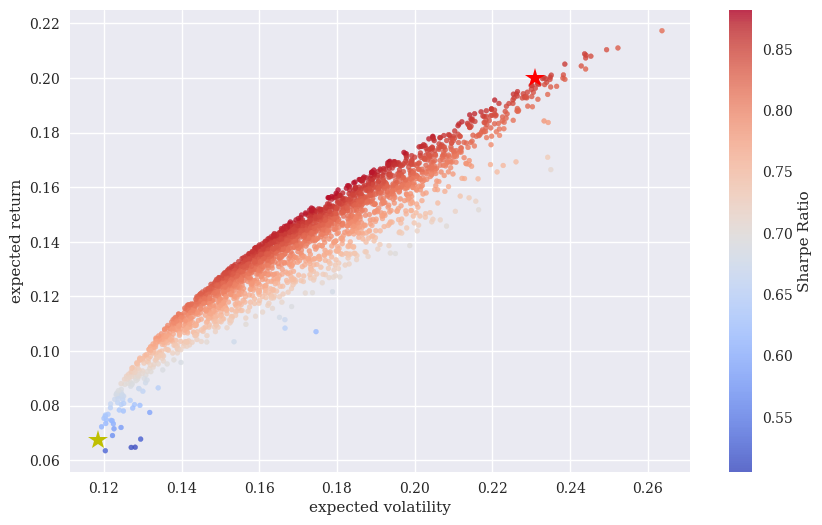

In [75]:
plt.figure(figsize=(10,6))
plt.scatter(pvols, prets, c=prets / pvols,
            marker ='.', alpha=0.8, cmap='coolwarm')
plt.plot(port_vol(optv['x']), port_ret(optv['x']),
         'y*', markersize=15.0)
plt.plot(port_vol(opts['x']), port_ret(opts['x']),
         'r*', markersize=15.0)
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe Ratio')
plt.show()

In [76]:
import scipy.interpolate as sci

In [77]:
ind = np.argmin(tvols)
evols = tvols[ind:]
erets = trets[ind:]

In [78]:
tck = sci.splrep(evols, erets)

In [79]:
def f(x):
    ''' Efficient frontier function (splines approximation).'''
    return sci.splev(x, tck, der=0)
def df(x):
    '''First derivative of efficent frontier function.'''
    return sci.splev(x, tck, der=1)

In [80]:
def equations(p, rf=0.01):
    eq1 = rf - p[0]
    eq2 = rf + p[1] * p[2] - f(p[2])
    eq3 = p[1] - df(p[2])
    return eq1, eq2, eq3

In [81]:
opt = sco.fsolve(equations, [0.01, 0.15, 0.18],
                full_output = False,
                xtol=1e-10)
              

In [82]:
np.round(equations(opt), 6)

array([ 0.,  0., -0.])

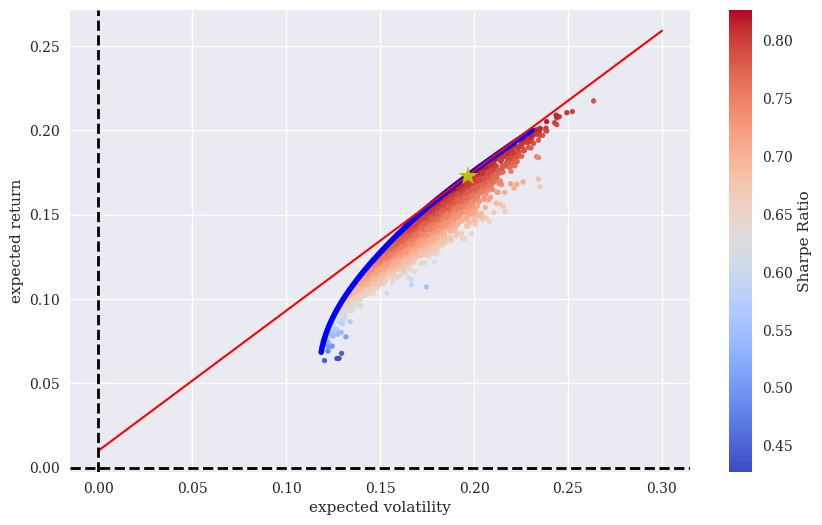

In [83]:
plt.figure(figsize=(10,6))
plt.scatter(pvols, prets, c=(prets - 0.01) / pvols,
            marker = '.',cmap='coolwarm')
plt.plot(evols, erets, 'b', lw=4.0)
cx = np.linspace(0.0, 0.3)
plt.plot(cx, opt[0] + opt[1] * cx, 'r', lw=1.5)
plt.plot(opt[2], f(opt[2]), 'y*', markersize=15.0)
plt.grid(True)
plt.axhline(0, color='k',ls='--', lw=2.0)
plt.axvline(0, color='k',ls='--', lw=2.0)
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe Ratio')
plt.show()

In [84]:
cons = ({'type':'eq', 'fun': lambda x: port_ret(x) - f(opt[2])},
        {'type':'eq', 'fun': lambda x: np.sum(x) - 1})
res = sco.minimize(port_vol, eweights, method = 'SLSQP',
                   bounds=bnds, constraints=cons)

In [85]:
res['x'].round(3)

array([0.507, 0.262, 0.   , 0.231])

In [86]:
port_ret(res['x'])

np.float64(0.1730405405749235)

In [87]:
port_vol(res['x'])

np.float64(0.19649612546161574)

In [88]:
port_ret(res['x']) / port_vol(res['x'])

np.float64(0.8806308021006035)

<span style='font-size:17px'><b>Mean-Variance Portfolio Optimization & the Capital Market line</b>

* <b>Efficient Frontier Construction:</b> Using $I = 2{,}500$ randomly generated weight combinations across AAPL, MSFT, SPY, and GLD, the Monte Carlo simulation maps the full investment opportunity set. Each portfolio is characterized by its annualized return $\mu_p = \mathbf{w}^\top \boldsymbol{\mu} \cdot 252$ and volatility $\sigma_p = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w} \cdot 252}$ with the color-coded Sharpe ratio $S = \mu_p / \sigma_p$ revealing the most efficent portfolios concentrated along the upper left boundary of the opportunity set.
* <b>Minimum Variance & Maximum Sharpe Portfolios:</b> Formal optimizatin via 'scipy.optimize.minimize' identifies two key portfolios on the frontier - the **minimum variance portfolio** (yellow star: $\sigma_p\approx 11.9\%$, $\mu_p \approx 20\%$, Sharpe $\approx 0.883$) heavily weighted toward AAPL and MSFT - reflecting the superior risk-adjusted performance of technology equities over the 2010-2024 sample period.
* <b>Capital Market Line & Tangency Potfolio:</b> Introducing a risk-free asset at $r_f = 1\%$, the tangency portfolio is found by solving the system of equations that enforce the CML slope conditions $p_1 = df(p_2)$ and frontier consistency $r_f + p_1 \cdot p_2 = f(p_2)$, where $f(\cdot)$ is the spline approximation of the efficent frontier. The solution converges to all-zero residuals, confirming the tangency point at $\sigma_p \approx 19.6\%$, $\mu_p \approx 17.3\%$, and Sharpe $\approx \textbf{0.881}$ - the single optimal risky portfolio all investors should hold regardless of risk appetite, scaling exposure via the risk-free asset.
* <b>Practical Implication:</b> The CML dominates the efficent frontier all risk levels - any target return can be achieved at lower volatility by combining the tangency portfolio with the risk-free asset rather than holding a suboptimal risky portfolio alone. The optimal weights $\mathbf{w}^* \approx [0.507, 0.262, 0.000, 0.231]$ confirm zero allocation to SPY, with capital concentrated in AAPL, MSFT, and GLD -  a result driven by the strong mean returns and diversification benefits observed over the sample period.


In [89]:
import numpy as np
import pandas as pd
import datetime as dt
from pylab import mpl, plt

In [90]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family']='serif'
np.random.seed(1000)
%matplotlib inline

In [91]:
x = np.linspace(0, 10, 500)
y = 4 + 2 * x + np.random.standard_normal(len(x)) * 2

In [92]:
reg = np.polyfit(x, y, 1)

In [93]:
reg

array([2.03384161, 3.77649234])

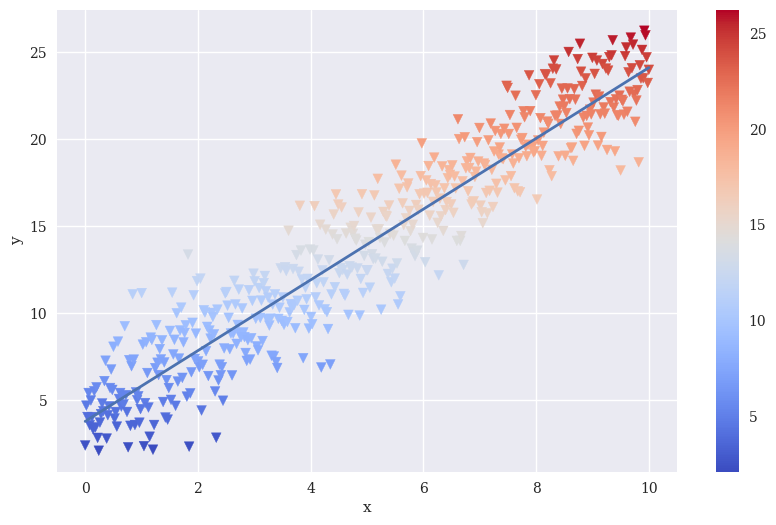

In [94]:
plt.figure(figsize=(10,6))
plt.scatter(x, y, c=y, marker='v', cmap='coolwarm')
plt.plot(x, reg[1] + reg[0] * x,  lw=2.0)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [95]:
!pip install pymc

In [96]:
import pymc as pm

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [97]:
%%time
with pm.Model() as model:
    # model
    alpha = pm.Normal('alpha', mu=0, sigma=20)
    beta = pm.Normal('beta', mu=0, sigma=10)
    sigma= pm.Uniform('sigma',lower=0, upper=10)
    y_est= alpha + beta * x
    likelihood = pm.Normal ('y', mu=y_est, sigma=sigma, 
                            observed=y)
    #inference
    start = pm.find_MAP()
    step = pm.NUTS()
    trace = pm.sample(50, tune=500, start=start,
                      progressbar=True)   

Output()

<timed exec>:12: FutureWarning: The `start` kwarg was renamed to `initvals` and can now do more. Please check the docstring.
Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 500 tune and 50 draw iterations (2_000 + 200 draws total) took 670 seconds.
The number of samples is too small to check convergence reliably.


CPU times: total: 1min 34s
Wall time: 11min 22s


In [98]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.776,0.171,3.476,4.155,0.019,0.022,87.0,39.0,1.05
beta,2.034,0.030,1.980,2.085,0.003,0.003,84.0,98.0,1.03
sigma,2.009,0.061,1.895,2.098,0.006,0.005,130.0,113.0,1.03


In [100]:
trace.posterior['alpha'].values[0, 0], trace.posterior['beta'].values[0, 0], trace.posterior['sigma'].values[0, 0]

(np.float64(3.9605223840671875),
 np.float64(1.993350470192434),
 np.float64(2.080120011524704))

In [102]:
import arviz as az
az.plot_trace(trace, lines=[('alpha', {}, 4), ('beta', {}, 2), ('sigma', {}, 2)])

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

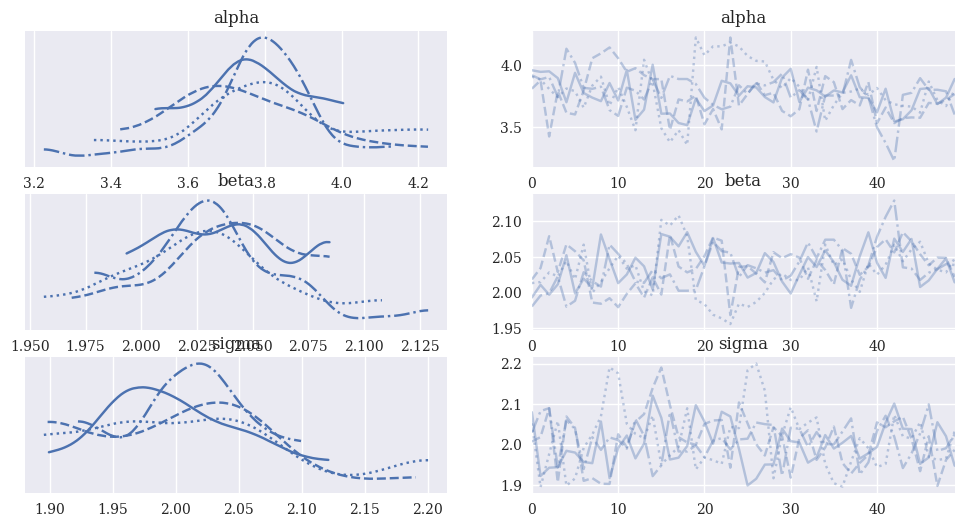

In [105]:
az.plot_trace(trace)
plt.show()

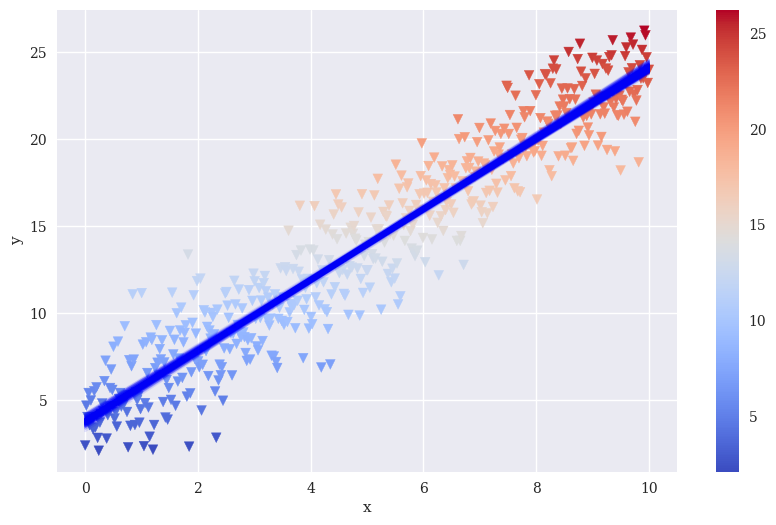

In [109]:
plt.figure(figsize=(10,6))
plt.scatter(x, y, c=y, marker='v', cmap='coolwarm')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')

# Flatten across chains and draws
alphas = trace.posterior['alpha'].values.flatten()
betas = trace.posterior['beta'].values.flatten()

for i in range(len(alphas)):
    plt.plot(x, alphas[i] + betas[i] * x, alpha=0.1, color='b')

plt.show()

In [110]:
tickers = ['GLD', 'GDX']
data = yf.download(tickers, start='2010-01-01', end='2024-01-01', auto_adjust=False)['Close']
data = data.dropna()
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,GDX,GLD
Date,,
2010-01-04,47.709999,109.800003
2010-01-05,48.169998,109.699997
2010-01-06,49.340000,111.510002
2010-01-07,49.099998,110.820000
2010-01-08,49.840000,111.370003


In [111]:
data / data.iloc[0]

Ticker,GDX,GLD
Date,,
2010-01-04,1.000000,1.000000
2010-01-05,1.009642,0.999089
2010-01-06,1.034165,1.015574
2010-01-07,1.029134,1.009290
2010-01-08,1.044645,1.014299
...,...,...
2023-12-22,0.661497,1.732878
2023-12-26,0.663802,1.746084
2023-12-27,0.670300,1.754007


In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GDX     3522 non-null   float64
 1   GLD     3522 non-null   float64
dtypes: float64(2)
memory usage: 82.5 KB


In [113]:
data.iloc[-1] / data.iloc[0] -1

Ticker
GDX   -0.350031
GLD    0.741075
dtype: float64

In [114]:
data.corr()

Ticker,GDX,GLD
Ticker,,
GDX,1.000000,0.454132
GLD,0.454132,1.000000


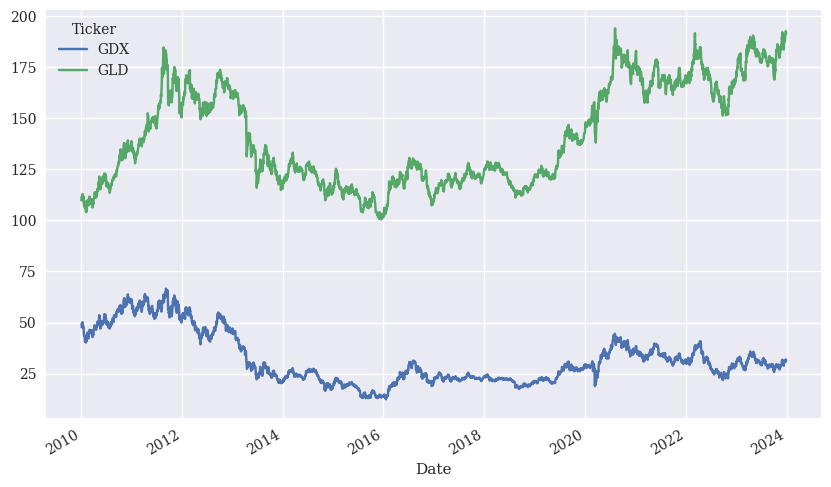

In [117]:
data.plot(figsize=(10,6))
plt.show()

In [118]:
data.index[:3]

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06'], dtype='datetime64[ns]', name='Date', freq=None)

In [120]:
mpl_dates = mpl.dates.date2num(data.index.to_pydatetime())
mpl_dates[:3]

array([14613., 14614., 14615.])

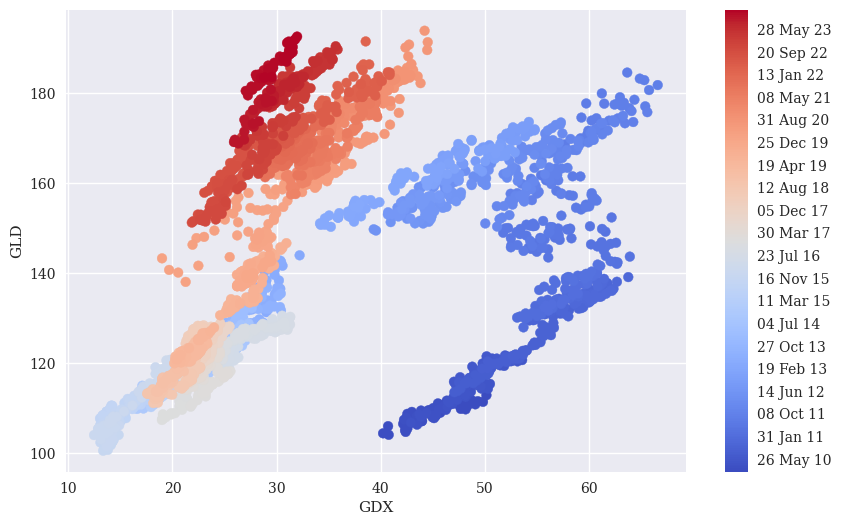

In [122]:
plt.figure(figsize=(10,6))
plt.scatter(data['GDX'], data['GLD'], c=mpl_dates,
            marker='o', cmap='coolwarm')
plt.xlabel('GDX')
plt.ylabel('GLD')
plt.colorbar(ticks=mpl.dates.DayLocator(interval=250),
             format=mpl.dates.DateFormatter('%d %b %y'));
plt.show()

In [127]:
with pm.Model() as model:
    alpha = pm.Normal('alpha', mu=0, sigma=20)
    beta = pm.Normal('beta', mu=0, sigma=20)
    sigma = pm.HalfNormal('sigma', sigma=10)
    
    y_est = alpha + beta * data['GDX'].values
    
    likelihood = pm.Normal('GLD', mu=y_est, sigma=sigma,
                          observed=data['GLD'].values)
    
    trace = pm.sample(100, tune=200, chains=2, cores=1, 
                     target_accept=0.9, progressbar=True)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta, sigma]


Output()

Sampling 2 chains for 200 tune and 100 draw iterations (400 + 200 draws total) took 4683 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [128]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,112.479,0.961,110.840,114.352,0.102,0.074,88.0,100.0,1.02
beta,0.898,0.028,0.855,0.954,0.003,0.003,73.0,94.0,1.03
sigma,21.915,0.234,21.459,22.292,0.021,0.015,123.0,95.0,1.02


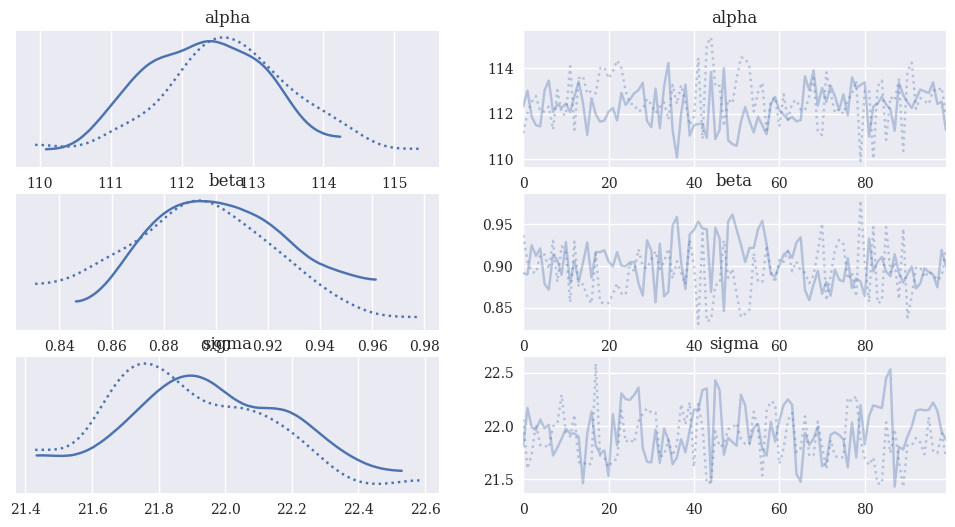

In [132]:
import arviz as az
az.plot_trace(trace)
plt.show()

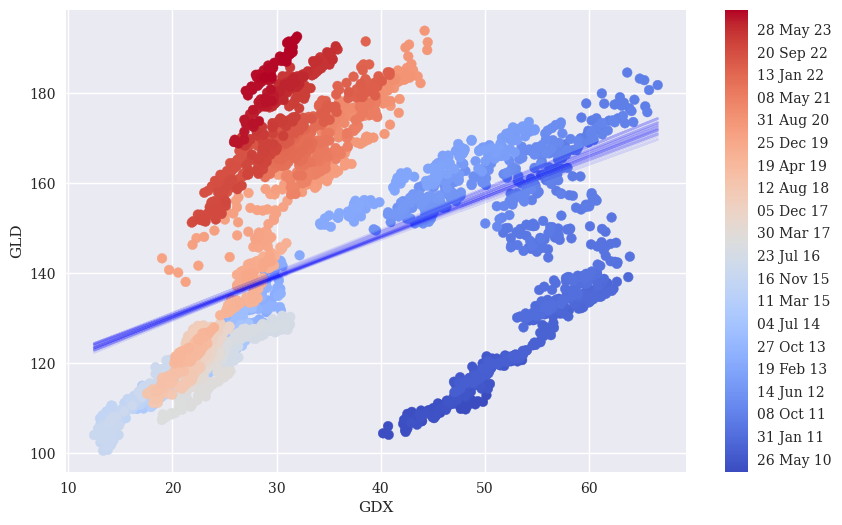

In [135]:
plt.figure(figsize=(10,6))
plt.scatter(data['GDX'], data['GLD'], c=mpl_dates,
           marker='o', cmap='coolwarm')
plt.xlabel('GDX')
plt.ylabel('GLD')

# Extract samples and flatten across chains
alphas = trace.posterior['alpha'].values.flatten()
betas = trace.posterior['beta'].values.flatten()

# Plot every Nth regression line to avoid visual overload
for i in range(0, len(alphas), 10):
    plt.plot(data['GDX'], alphas[i] + betas[i] * data['GDX'],
             alpha=0.1, color='b')

plt.colorbar(ticks=mpl.dates.DayLocator(interval=250),
            format=mpl.dates.DateFormatter('%d %b %y'))
plt.show()

In [136]:
from pymc.distributions.timeseries import GaussianRandomWalk

In [137]:
subsample_alpha = 50
subsample_beta = 50

In [141]:
from pymc.distributions.timeseries import GaussianRandomWalk

subsample_alpha = 50
subsample_beta = 50

model_randomwalk = pm.Model()
with model_randomwalk:
    sigma_alpha = pm.Exponential('sig_alpha', 1. / .02, initval=.1)
    sigma_beta = pm.Exponential('sig_beta', 1. / .02, initval=.1)
    
    alpha = GaussianRandomWalk('alpha', sigma_alpha ** -2,
                               shape=int(2100 / subsample_alpha))
    beta = GaussianRandomWalk('beta', sigma_beta ** -2,
                              shape=int(2100 / subsample_beta))
    
    alpha_r = np.repeat(alpha, subsample_alpha)
    beta_r = np.repeat(beta, subsample_beta)
    
    regression = alpha_r + beta_r * data['GDX'].values[:2100]
    
    sd = pm.Uniform('sd', 0, 20)
    likelihood = pm.Normal('GLD', mu=regression, sigma=sd,
                          observed=data['GLD'].values[:2100])

C:\Users\wyatt\anaconda3\Lib\site-packages\pymc\distributions\timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
C:\Users\wyatt\anaconda3\Lib\site-packages\pymc\distributions\timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


In [150]:
%%time
with model_randomwalk:
    trace_rw = pm.sample(100, tune=100, cores=2, chains=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sig_alpha, sig_beta, alpha, beta, sd]


Output()

Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 1411 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: total: 1min 53s
Wall time: 23min 38s
